# Introduction


This notebook is based on a tutorial from goo.gle/ai-kaggle-keras-gemma about how to fine-tune **Gemma** on a **Kaggle** dataset and share the model with the community.  


## Model used

We are using **Gemma 3** model with 270M parameters, Keras, English version, v3.

## Dataset

We will fine-tune **Gemma 3 270M** using a [Medical Q & A](https://www.kaggle.com/datasets/gpreda/medquad/) dataset. This is a subset of the full public dataset [Healthcare NLP: LLMs, Transformers, Datasets](https://www.kaggle.com/datasets/jpmiller/layoutlm).



# Prepare packages


We will install updated version of Keras, KerasNLP, which we need for fine-tuning, and other dependencies.

In [ ]:
!pip install -q -U keras-nlp keras
!pip install -q -U "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

In [ ]:
!pip install -q -U kagglehub

<font color="red">Restart the Kernel before runing the rest of the Notebook!</font>

With Keras 3, we can run workflows on one of three backends: **TensorFlow**, **JAX**, and **PyTorch**.

For this Notebook, we will configure the backend for **JAX**.   

We are also setting the parameter `XLA_PYTHON_CLIENT_MEM_FRACTION` to avoid memory fragmentation on **JAX** backend.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax" # you can also use tensorflow or torch
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90" # avoid memory fragmentation on JAX backend.
os.environ["JAX_PLATFORMS"] = ""

Once installed the additional packages, we can now include them.

In [2]:
import keras
import keras_nlp
from keras_nlp.samplers import TopKSampler
from time import time
import csv

print("KerasNLP version: ", keras_nlp.__version__)
print("Keras version: ", keras.__version__)

KerasNLP version:  0.25.1
Keras version:  3.12.1


# Load the model

We load the model `gemma_3_270M` using `keras_nlp`.

In [3]:
gemma_lm = keras_nlp.models.Gemma3CausalLM.from_preset("gemma3_270m")

2026-04-29 19:08:10.530837: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777489690.532090   25302 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 512 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Let's print the summary of the model loaded.

In [4]:
gemma_lm.summary()

Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)                            │                      Vocab size: 262,144 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma3_backbone               │ (None, None, 640)         │     268,098,176 │ padding_mask[0][0],        │
│ (Gemma3Backbone)              │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 262144)      │     167,772,160 │ gemma3_backbone[0][0]      │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 268,098,176 (1022.71 MB)

 Trainable params: 268,098,176 (1022.71 MB)

 Non-trainable params: 0 (0.00 B)

# Prepare the training data

Let's create a configuration class.

In [5]:
class CFG:
 
    max_length = 512
    data_size = 2560
    lora_rank = 8
    epochs = 10
    batch_size = 2

cfg = CFG()

We prepare the **Medical Q & A** data for training. We will load the data using the template where, for each data that will be included in the training set, we provide pairs of questions and answers.

In [6]:
data = []

# The CSV file contains two columns 'question' and 'answer'
with open("medquad.csv", mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # we replace with 'prompts' and 'responses'
        data.append({"prompts": row['question'], 'responses': row['answer']})

In [7]:
print(f"Data size: {len(data)}")

Data size: 16412


Let's limit the data to **2560 rows** of questions and answers. We do this to limit the training time for this demonstration Notebook. You can get back and fine-tune using entire dataset or use your own data size.

In [8]:
train_data = data[:cfg.data_size]

In [9]:
test_data = data[cfg.data_size:cfg.data_size + 100]

In [10]:
print(f"Train data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 2560
Test data size: 100


We then prepare a dataset for training (we will use for train & valid) and one for testing.

In [11]:
import tensorflow as tf

dataset = tf.data.Dataset.from_generator(
    lambda: (item for item in train_data),
    output_signature={
        "prompts": tf.TensorSpec(shape=(), dtype=tf.string),
        "responses": tf.TensorSpec(shape=(), dtype=tf.string),
    }
)

test_dataset = tf.data.Dataset.from_generator(
    lambda: (item for item in test_data),
    output_signature={
        "prompts": tf.TensorSpec(shape=(), dtype=tf.string),
        "responses": tf.TensorSpec(shape=(), dtype=tf.string),
    }
)

Prepare train/validation subsets.

In [14]:
import math
val_fraction = 0.2
dataset_size = cfg.data_size
valid_size = math.ceil(dataset_size * val_fraction)
train_size = math.ceil((1 - val_fraction) * dataset_size)

steps_per_epoch = math.ceil(train_size / cfg.batch_size)
validation_steps = math.ceil(val_size / cfg.batch_size)

print(f"Train size: {train_size}; Valid size: {valid_size}")
print(f"Step/epoch: {steps_per_epoch} Valid steps: {validation_steps}")

Train size: 2048; Valid size: 512
Step/epoch: 1024 Valid steps: 256


In [15]:

train_dataset = dataset.skip(valid_size)
val_dataset = dataset.take(valid_size)

train_dataset = (
    train_dataset
    .shuffle(train_size)
    .batch(cfg.batch_size)
    .repeat()
)
val_dataset = (
    val_dataset
    .batch(cfg.batch_size)
    .repeat()
)

                                                               

Prepare test dataset.

In [16]:
test_dataset = test_dataset.batch(cfg.batch_size)

# Check model inference before fine tuning

We wil first check the model before proceeding to fine-tuning. We will test it with some questions about medical matters.  

First, we will define an utility function to display the query and answer from LLM.  

The first function is for the case when data is in text format.

In [17]:
from IPython.display import display, Markdown
def colorize_text(text):
    for word, color in zip(["Category", "Question", "Answer"], ["blue", "red", "green"]):
        text = text.replace(f"{word}:", f"\n\n**<font color='{color}'>{word}:</font>**")
    return text

The second function is for the case when data is in the dictionary format.

In [18]:
def colorize_text_dict(sample):
    """
    sample: dict with keys 'prompts' and 'responses'
    """
    colored_text = ""
    colored_text += f"**<font color='red'>Question:</font>** {sample['prompts']}\n\n"
    colored_text += f"**<font color='green'>Answer:</font>** {sample['responses']}\n\n"
    return colored_text

Let's check how we can display the content of one data input using the `colorize_text` function.

In [19]:
print(data[3])

{'prompts': 'What are the treatments for Glaucoma ?', 'responses': 'Although open-angle glaucoma cannot be cured, it can usually be controlled. While treatments may save remaining vision, they do not improve sight already lost from glaucoma. The most common treatments for glaucoma are medication and surgery. Medications  Medications for glaucoma may be either in the form of eye drops or pills. Some drugs reduce pressure by slowing the flow of fluid into the eye. Others help to improve fluid drainage. (Watch the video to learn more about coping with glaucoma. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) For most people with glaucoma, regular use of medications will control the increased fluid pressure. But, these drugs may stop working over time. Or, they may cause side effects. If a problem occurs, the eye care professional may select other drugs, change the dose, or suggest other ways to 

In [20]:
display(Markdown(colorize_text_dict(data[3])))

**<font color='red'>Question:</font>** What are the treatments for Glaucoma ?

**<font color='green'>Answer:</font>** Although open-angle glaucoma cannot be cured, it can usually be controlled. While treatments may save remaining vision, they do not improve sight already lost from glaucoma. The most common treatments for glaucoma are medication and surgery. Medications  Medications for glaucoma may be either in the form of eye drops or pills. Some drugs reduce pressure by slowing the flow of fluid into the eye. Others help to improve fluid drainage. (Watch the video to learn more about coping with glaucoma. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) For most people with glaucoma, regular use of medications will control the increased fluid pressure. But, these drugs may stop working over time. Or, they may cause side effects. If a problem occurs, the eye care professional may select other drugs, change the dose, or suggest other ways to deal with the problem.  Read or listen to ways some patients are coping with glaucoma. Surgery Laser surgery is another treatment for glaucoma. During laser surgery, a strong beam of light is focused on the part of the anterior chamber where the fluid leaves the eye. This results in a series of small changes that makes it easier for fluid to exit the eye. Over time, the effect of laser surgery may wear off. Patients who have this form of surgery may need to keep taking glaucoma drugs. Researching Causes and Treatments Through studies in the laboratory and with patients, NEI is seeking better ways to detect, treat, and prevent vision loss in people with glaucoma. For example, researchers have discovered genes that could help explain how glaucoma damages the eye. NEI also is supporting studies to learn more about who is likely to get glaucoma, when to treat people who have increased eye pressure, and which treatment to use first.



# Fine-tunning with LoRA   


We are using now **LoRA** for fine-tunning. **LoRA** stands for **Low Rank Adaptation** and is a method for modifying a pretrained model (for example, an LLM or vision transformer) to better suit a specific, often smaller, dataset by **adjusting only a small, low-rank subset of the model's parameters**.


The rank used here for LoRA controls the number of parameters that will be recalculated during fine-tuning.

In [21]:
# Enable LoRA for the model and set the LoRA rank to cfg.lora_rank.
gemma_lm.backbone.enable_lora(rank=cfg.lora_rank)
gemma_lm.summary()

Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)                            │                      Vocab size: 262,144 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma3_backbone               │ (None, None, 640)         │     268,632,704 │ padding_mask[0][0],        │
│ (Gemma3Backbone)              │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 262144)      │     167,772,160 │ gemma3_backbone[0][0]      │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 268,632,704 (1.00 GB)

 Trainable params: 534,528 (2.04 MB)

 Non-trainable params: 268,098,176 (1022.71 MB)

In [22]:
# Fine-tune on the Medical QA dataset.

# Limit the input sequence length to 128 (to control memory usage).
gemma_lm.preprocessor.sequence_length = cfg.max_length
# Use AdamW (a common optimizer for transformer models).
optimizer = keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=0.01,
)
# Exclude layernorm and bias terms from decay.
optimizer.exclude_from_weight_decay(var_names=["bias", "scale"])

gemma_lm.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


In [23]:
history = gemma_lm.fit(train_dataset,
                       validation_data=val_dataset,
                       epochs=cfg.epochs,
                       steps_per_epoch=steps_per_epoch,
                       validation_steps=validation_steps,
                      )

2026-04-29 19:12:07.792619: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Epoch 1/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 158s 104ms/step - loss: 0.9293 - sparse_categorical_accuracy: 0.5569 - val_loss: 0.9266 - val_sparse_categorical_accuracy: 0.5531
Epoch 2/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 97s 94ms/step - loss: 0.8516 - sparse_categorical_accuracy: 0.5868 - val_loss: 0.9341 - val_sparse_categorical_accuracy: 0.5520
Epoch 3/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 97s 95ms/step - loss: 0.7990 - sparse_categorical_accuracy: 0.6123 - val_loss: 0.9394 - val_sparse_categorical_accuracy: 0.5519
Epoch 4/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 97s 95ms/step - loss: 0.7658 - sparse_categorical_accuracy: 0.6283 - val_loss: 0.9397 - val_sparse_categorical_accuracy: 0.5512
Epoch 5/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 97s 95ms/step - loss: 0.7441 - sparse_categorical_accuracy: 0.6389 - val_loss: 0.9398 - val_sparse_categorical_accuracy: 0.5513
Epoch 6/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 97s 94ms/step - loss: 0.7270 - sparse_categorical_accuracy: 0.6476 - val_loss: 0.9328 - val_sparse_categor

# Train and validation loss & accuracy

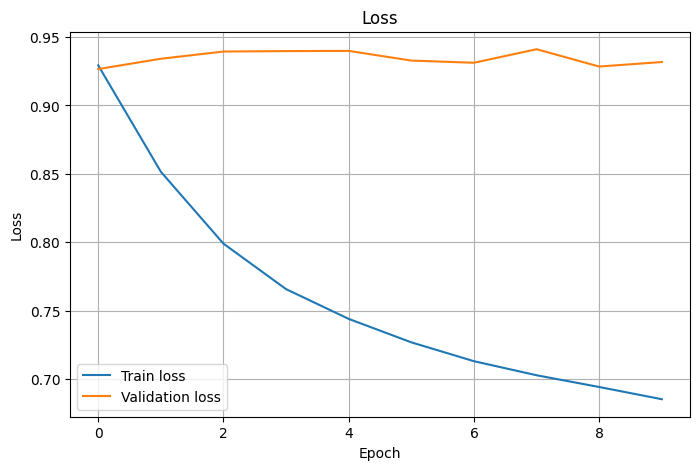

In [24]:
import matplotlib.pyplot as plt

hist = history.history

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(hist["loss"], label="Train loss")
plt.plot(hist["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

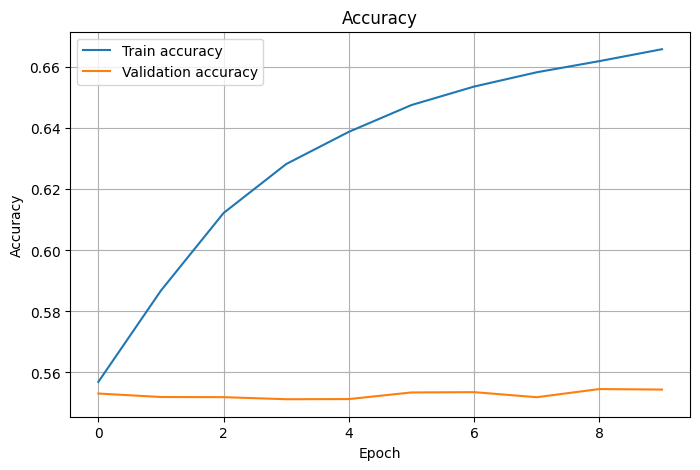

In [25]:
acc_key = "sparse_categorical_accuracy"
val_acc_key = "val_sparse_categorical_accuracy"

plt.figure(figsize=(8, 5))
plt.plot(hist[acc_key], label="Train accuracy")
plt.plot(hist[val_acc_key], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")
plt.grid(True)
plt.show()

# Inference after fine tuning


Let's try again now the two examples from above. We will run now the queries through the fine-tuned model.

In [31]:
template = "Question:\n{question}\n\nAnswer:\n{answer}"
prompt = template.format(
    question="What are the complications of Paget's Disease of Bone ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the complications of Paget's Disease of Bone ?



**<font color='green'>Answer:</font>**
Paget's disease of bone can cause bone pain, bone loss, and bone deformity. It can also cause bone fractures.    Paget's disease of bone can be caused by a number of things. It can be caused by a disease, such as a virus, cancer, or infection. It can also be caused by a reaction to certain medicines.    Paget's disease of bone can be difficult to diagnose. It is usually diagnosed by a bone scan.    Treatment for Paget's disease of bone depends on the cause. It may include medicines, surgery, or bone marrow transplant.    NIH: National Institute of Arthritis and Musculoskeletal and Skin Diseases

In [32]:
prompt = template.format(
    question="What are the treatments for Diabetes ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the treatments for Diabetes ?



**<font color='green'>Answer:</font>**
There are different types of treatment for people with diabetes. Some treatments are for the symptoms of diabetes, such as       -  Type 1 diabetes is treated with insulin.    -  Type 2 diabetes is treated with a combination of insulin and a drug called glipizide.    -  People with type 1 diabetes may need to take insulin and other medicines to control their blood sugar levels.    -  People with type 2 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 2 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 2 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their blood sugar levels.    -  People with type 1 diabetes may need to take medicines to control their

In [33]:
prompt = template.format(
    question="What are the symptoms of Glaucoma ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the symptoms of Glaucoma ?



**<font color='green'>Answer:</font>**
The signs and symptoms of glaucoma depend on the type of glaucoma. The signs and symptoms include       - Blurred vision    - Double vision    - Numbness or pain in the eye    - Sensitivity to light    - Sensitivity to sound    - Sensitivity to touch    - Sensitivity to pain    - Numbness or pain in the eye       Glaucoma can also cause vision loss.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain.    Glaucoma can also cause eye pain

In [34]:
prompt = template.format(
    question="What are the treatments for Glaucoma ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the treatments for Glaucoma ?



**<font color='green'>Answer:</font>**
The treatment for glaucoma depends on the type of glaucoma. The treatment for glaucoma depends on the following:         - The severity of the eye damage.    - The amount of fluid in the eye.    - The amount of time the eye has been open.    - The type of glaucoma.    - The number of patients with the disease.    - The severity of the disease.    - The presence of other eye diseases.    - The results of an eye exam.    - The results of a laboratory test.    - The patient's medical records.

In [35]:
prompt = template.format(
    question="What causes High Blood Pressure ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What causes High Blood Pressure ?



**<font color='green'>Answer:</font>**
High blood pressure is a disease in which your blood pressure is too high. It can lead to heart disease, stroke, and other problems. It can also cause other problems, such as kidney problems, high blood sugar, and high blood cholesterol.    High blood pressure can be caused by many things, including    - High blood pressure medication    - High blood pressure from a heart attack or stroke    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a high blood cholesterol level    - High blood pressure from a high blood sugar level    - High blood pressure from a high blood cholesterol level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a high blood cholesterol level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a high blood cholesterol level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure from a kidney disease    - High blood pressure from a high blood sugar level    - High blood pressure

# Model testing

In [39]:
!pip install -q rouge-score bert-score

Prepare data for testing

In [40]:
from tqdm import tqdm

predictions = []
references = []

for batch in tqdm(test_dataset):
    outputs = gemma_lm.generate(batch["prompts"])
    
    predictions.extend(outputs)
    references.extend(batch["responses"])

50it [02:25,  2.91s/it]


In [41]:
from collections import Counter

def f1_score(pred, ref):
    pred_tokens = pred.split()
    ref_tokens = ref.split()
    
    common = Counter(pred_tokens) & Counter(ref_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(ref_tokens)

    return 2 * precision * recall / (precision + recall)

In [42]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def rouge_scores(pred, ref):
    scores = scorer.score(ref, pred)
    return scores

In [44]:
f1s = [f1_score(str(p), str(r)) for p, r in zip(predictions, references)]
r_s = [rouge_scores(str(p), str(r)) for p, r in zip(predictions, references)]

print("F1:", sum(f1s)/len(f1s))

precision_I = [r_s_item.get("rouge1").precision for r_s_item in r_s]
recall_I = [r_s_item.get("rouge1").recall for r_s_item in r_s]
f1_score_I = [r_s_item.get("rouge1").fmeasure for r_s_item in r_s]

precisionL = [r_s_item.get("rougeL").precision for r_s_item in r_s]
recallL = [r_s_item.get("rougeL").recall for r_s_item in r_s]
f1_scoreL = [r_s_item.get("rougeL").fmeasure for r_s_item in r_s]

print("RougeI precision: ", sum(precision_I)/len(precision_I))
print("RougeI recall: ", sum(recall_I)/len(recall_I))
print("RougeI f1_score: ", sum(f1_score_I)/len(f1_score_I))

print("RougeL precision: ", sum(precisionL)/len(precisionL))
print("RougeL recall: ", sum(recallL)/len(recallL))
print("RougeL f1_score: ", sum(f1_scoreL)/len(f1_scoreL))

F1: 0.13747738191683592
RougeI precision:  0.16612185141686914
RougeI recall:  0.24937085061979122
RougeI f1_score:  0.16486823225826072
RougeL precision:  0.12623897775500997
RougeL recall:  0.19433588189818995
RougeL f1_score:  0.12557871101367868


# Conclusions

We saw how to fine tune **Gemma 3 270M"** model using **LoRA** and **KerasNLP**.

We only used a subset of the **Medical Q & A** data to perform the fine tuning. If you have access to more computational resources, please feel free to improve the fine-tuned model by:
* Adding more data for training from the available dataset.
* Increase the `max_length` (currently 256).
* Increasing the rank parameter used in fine-tuning.